In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('../data/car_price_prediction.csv')
data.head()

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4


In [3]:
data.shape

(19237, 18)

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                19237 non-null  int64  
 1   Price             19237 non-null  int64  
 2   Levy              19237 non-null  str    
 3   Manufacturer      19237 non-null  str    
 4   Model             19237 non-null  str    
 5   Prod. year        19237 non-null  int64  
 6   Category          19237 non-null  str    
 7   Leather interior  19237 non-null  str    
 8   Fuel type         19237 non-null  str    
 9   Engine volume     19237 non-null  str    
 10  Mileage           19237 non-null  str    
 11  Cylinders         19237 non-null  float64
 12  Gear box type     19237 non-null  str    
 13  Drive wheels      19237 non-null  str    
 14  Doors             19237 non-null  str    
 15  Wheel             19237 non-null  str    
 16  Color             19237 non-null  str    
 17  Airb

In [5]:
data.isna().sum()

ID                  0
Price               0
Levy                0
Manufacturer        0
Model               0
Prod. year          0
Category            0
Leather interior    0
Fuel type           0
Engine volume       0
Mileage             0
Cylinders           0
Gear box type       0
Drive wheels        0
Doors               0
Wheel               0
Color               0
Airbags             0
dtype: int64

In [6]:
data.duplicated().sum()

np.int64(313)

In [7]:
data.drop_duplicates(inplace=True)
data.shape

(18924, 18)

In [8]:
data.describe()

,ID,Price,Prod. year,Cylinders,Airbags
count,1.892400e+04,1.892400e+04,18924.000000,18924.000000,18924.000000
mean,4.557538e+07,1.858744e+04,2010.914236,4.580216,6.568379
std,9.375468e+05,1.921356e+05,5.665749,1.200223,4.322323
min,2.074688e+07,1.000000e+00,1939.000000,1.000000,0.000000
25%,4.569501e+07,5.331000e+03,2009.000000,4.000000,4.000000
50%,4.577191e+07,1.317200e+04,2012.000000,4.000000,6.000000
75%,4.580174e+07,2.206300e+04,2015.000000,4.000000,12.000000
max,4.581665e+07,2.630750e+07,2020.000000,16.000000,16.000000


In [9]:
data.select_dtypes(include=['object','str','category','string']).describe()

,Levy,Manufacturer,Model,Category,Leather interior,Fuel type,Engine volume,Mileage,Gear box type,Drive wheels,Doors,Wheel,Color
count,18924,18924,18924,18924,18924,18924,18924,18924,18924,18924,18924,18924,18924
unique,559,65,1590,11,2,7,107,7687,4,3,3,2,16
top,-,HYUNDAI,Prius,Sedan,Yes,Petrol,2,0 km,Automatic,Front,04-May,Left wheel,Black
freq,5709,3729,1069,8600,13731,9944,3856,714,13282,12695,18032,17471,4944


In [10]:
def top_and_bottom_combined(df,col,n=5):
    top_counts = df[col].value_counts().head(n)
    bottom_counts = df[col].value_counts().tail(n)
    
    combined = pd.concat([top_counts, bottom_counts], axis=0)
    return combined

for col in data.select_dtypes(include=['object','str','category','string']):
    print(f'{col} value counts:')
    print(top_and_bottom_combined(data, col))
    print('30 Unique values:', data[col].unique()[:30])
    print('-----------------------------------')

Levy value counts:
Levy
-       5709
765      482
891      453
639      403
640      398
2308       1
4860       1
1641       1
1045       1
1901       1
Name: count, dtype: int64
30 Unique values: <StringArray>
['1399', '1018',    '-',  '862',  '446',  '891',  '761',  '751',  '394',
 '1053', '1055', '1079',  '810', '2386', '1850',  '531',  '586', '1249',
 '2455',  '583', '1537', '1288',  '915', '1750',  '707', '1077', '1486',
 '1091',  '650',  '382']
Length: 30, dtype: str
-----------------------------------
Manufacturer value counts:
Manufacturer
HYUNDAI          3729
TOYOTA           3606
MERCEDES-BENZ    2043
FORD             1088
CHEVROLET        1047
LAMBORGHINI         1
PONTIAC             1
SATURN              1
ASTON MARTIN        1
GREATWALL           1
Name: count, dtype: int64
30 Unique values: <StringArray>
[        'LEXUS',     'CHEVROLET',         'HONDA',          'FORD',
       'HYUNDAI',        'TOYOTA', 'MERCEDES-BENZ',          'OPEL',
       'PORSCHE',           '

In [11]:
# Fix the problems
# Replace '-' with 0 in the 'Levy' column and convert it to numeric
data['Levy'] = pd.to_numeric(data['Levy'], errors='coerce').fillna(0).astype(int)

In [12]:
data['Engine volume'] = data['Engine volume'].str.replace('Turbo', '')
data['Engine volume'] = pd.to_numeric(data['Engine volume'])

In [13]:
data['Mileage'] = data['Mileage'].str.replace(' km', '')
data['Mileage'] = pd.to_numeric(data['Mileage'])

In [14]:
data.drop(['Doors'],axis=1,inplace=True)

In [15]:
data.info()

<class 'pandas.DataFrame'>
Index: 18924 entries, 0 to 19236
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                18924 non-null  int64  
 1   Price             18924 non-null  int64  
 2   Levy              18924 non-null  int64  
 3   Manufacturer      18924 non-null  str    
 4   Model             18924 non-null  str    
 5   Prod. year        18924 non-null  int64  
 6   Category          18924 non-null  str    
 7   Leather interior  18924 non-null  str    
 8   Fuel type         18924 non-null  str    
 9   Engine volume     18924 non-null  float64
 10  Mileage           18924 non-null  int64  
 11  Cylinders         18924 non-null  float64
 12  Gear box type     18924 non-null  str    
 13  Drive wheels      18924 non-null  str    
 14  Wheel             18924 non-null  str    
 15  Color             18924 non-null  str    
 16  Airbags           18924 non-null  int64  
dtypes: float6

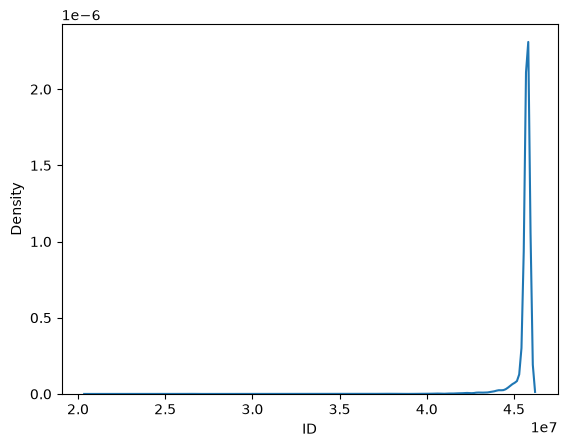

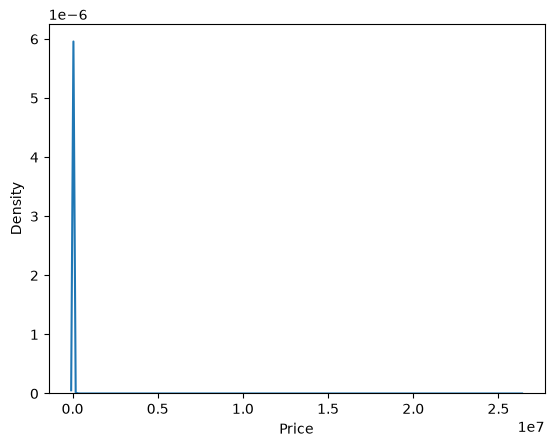

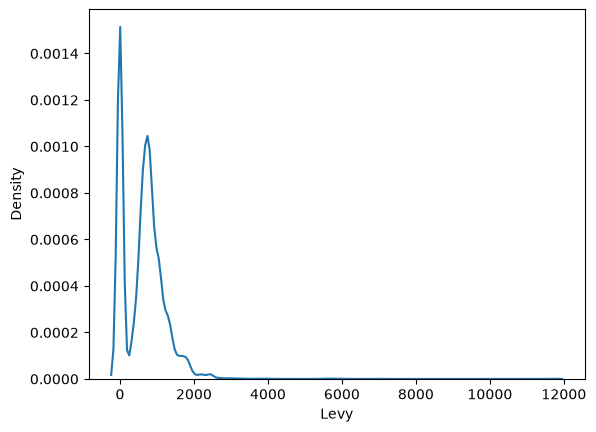

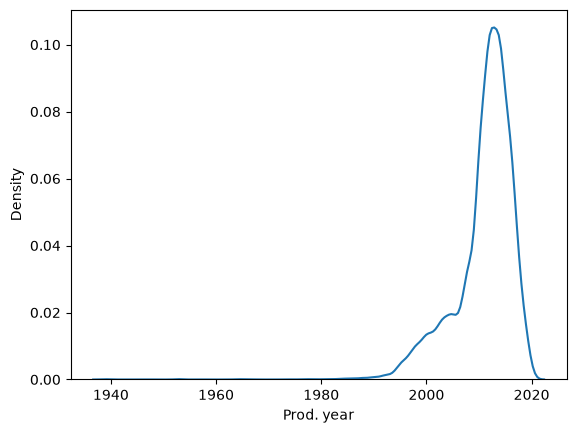

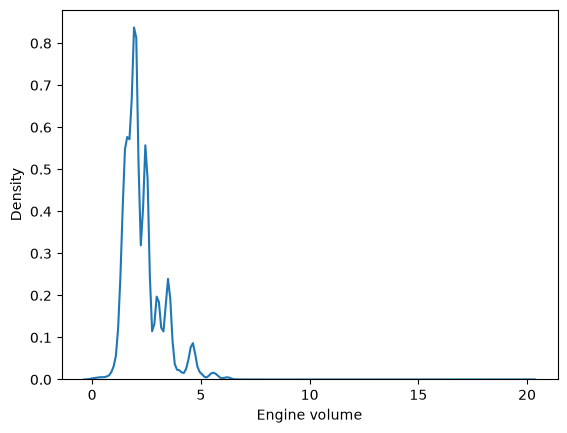

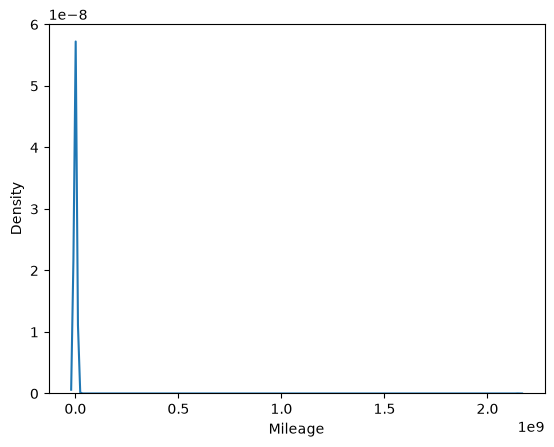

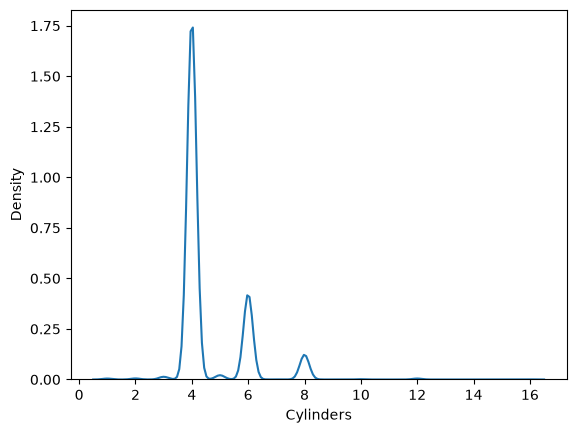

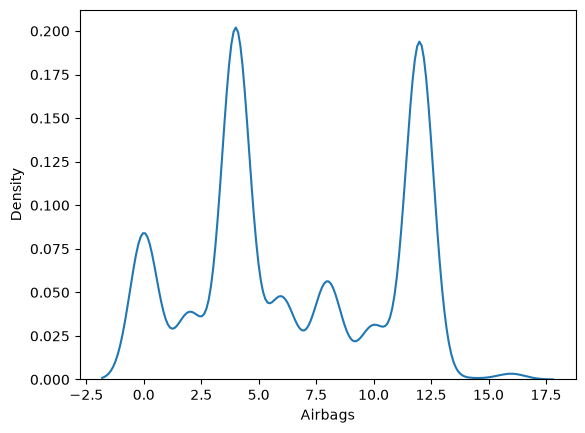

In [16]:
for col in data.select_dtypes('number').columns:
    sns.kdeplot(data[col])
    plt.show()

c:\Users\Ibrahem\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


<Axes: xlabel='Mileage', ylabel='Density'>

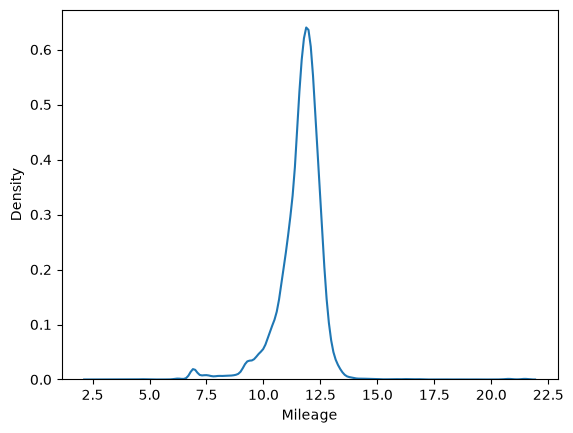

In [17]:
sns.kdeplot(np.log(data['Mileage']))

<Axes: >

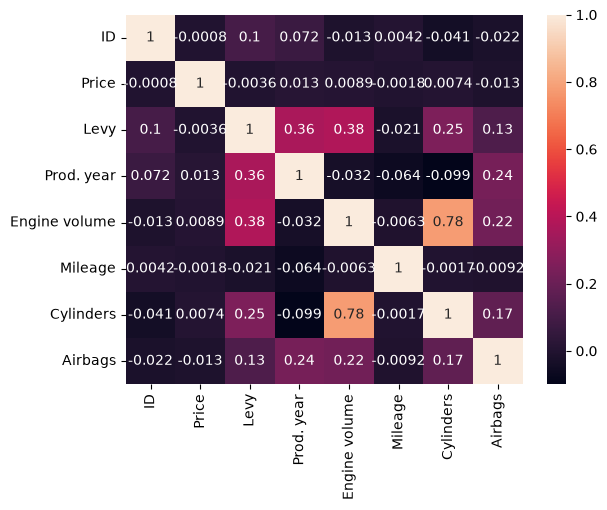

In [18]:
sns.heatmap(data.select_dtypes('number').corr(),annot=True)

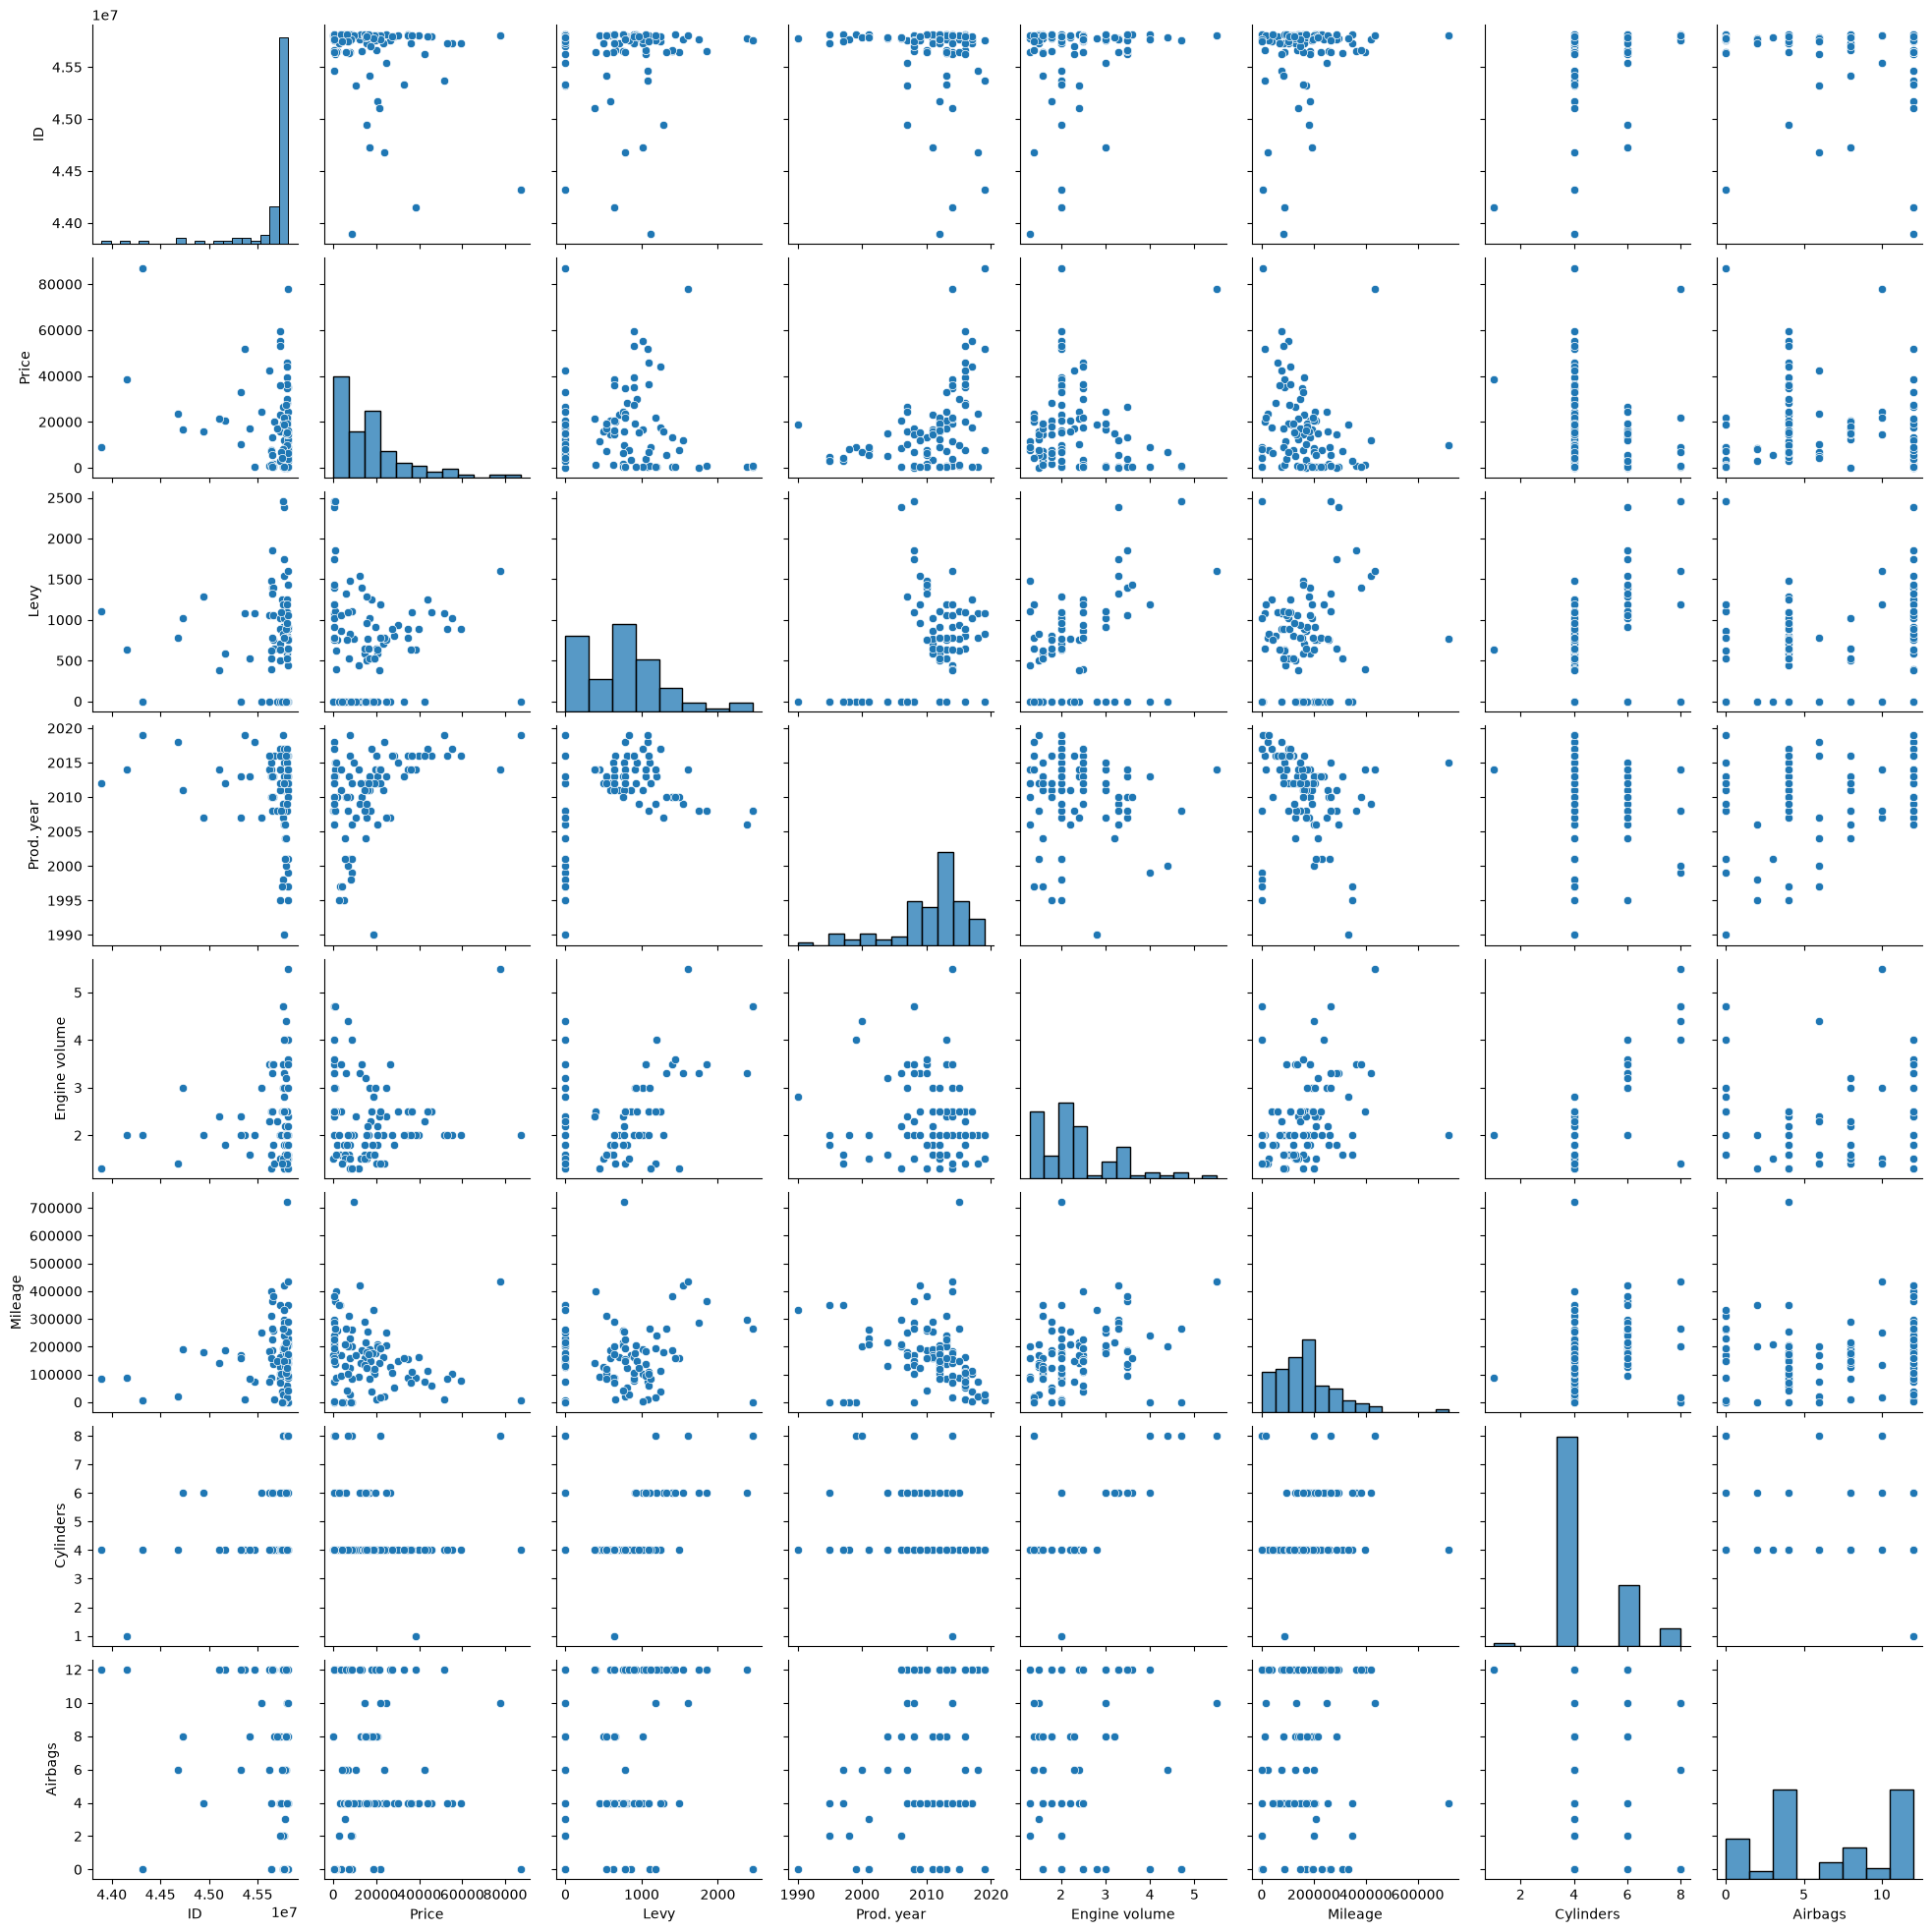

In [19]:
sns.pairplot(data[:100])

<Axes: ylabel='Price'>

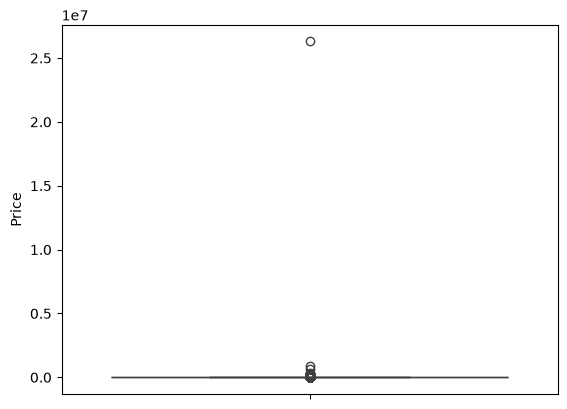

In [20]:
sns.boxplot(data['Price'])

In [21]:
data[data['Price'] > 5e5]

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Wheel,Color,Airbags
1225,45795524,627220,0,MERCEDES-BENZ,G 65 AMG 63AMG,2020,Jeep,Yes,Petrol,6.3,0,8.0,Tiptronic,4x4,Left wheel,Black,12
8541,45761204,872946,2067,LAMBORGHINI,Urus,2019,Universal,Yes,Petrol,4.0,2531,8.0,Tiptronic,4x4,Left wheel,Black,0
16983,45812886,26307500,0,OPEL,Combo,1999,Goods wagon,No,Diesel,1.7,99999,4.0,Manual,Front,Left wheel,Blue,0


<Axes: ylabel='Levy'>

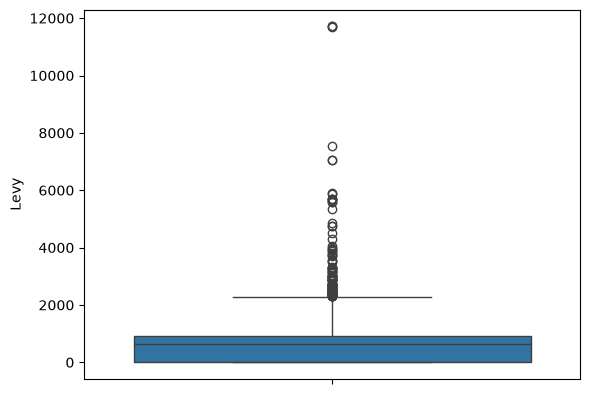

In [22]:
sns.boxplot(data['Levy'])

<Axes: ylabel='Mileage'>

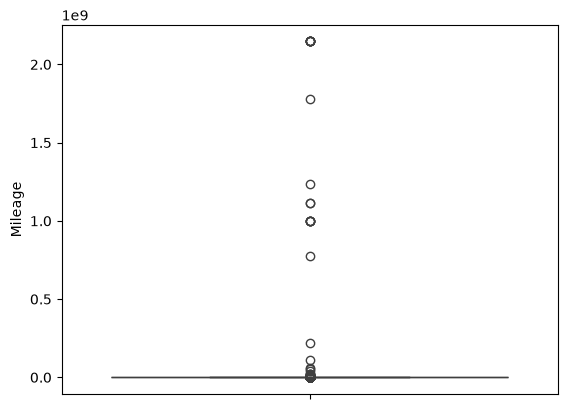

In [23]:
sns.boxplot(data['Mileage'])

In [24]:
def clean_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

In [25]:
data = clean_outliers(data, 'Mileage')
data = clean_outliers(data, 'Levy')
data = clean_outliers(data, 'Price')

In [26]:
data.shape

(17138, 17)

C:\Users\Ibrahem\AppData\Local\Temp\ipykernel_19892\4288405009.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in data.select_dtypes('object'):


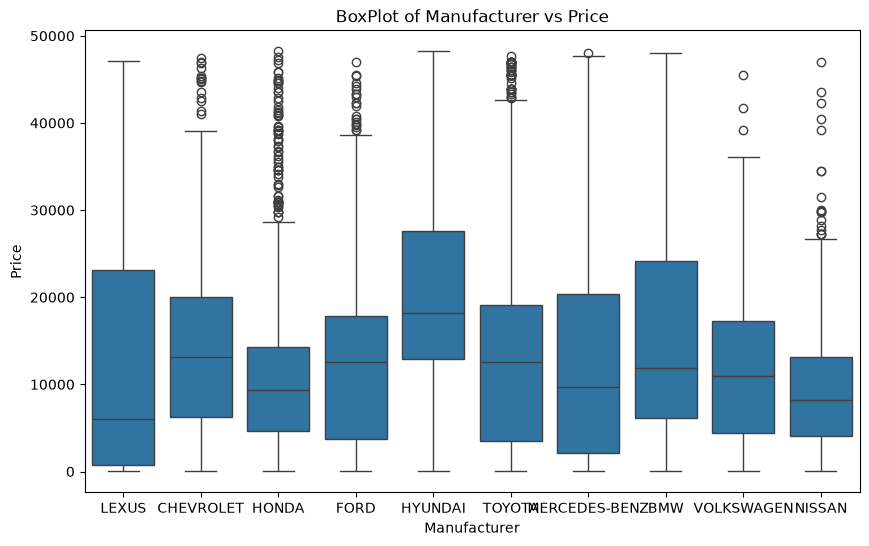

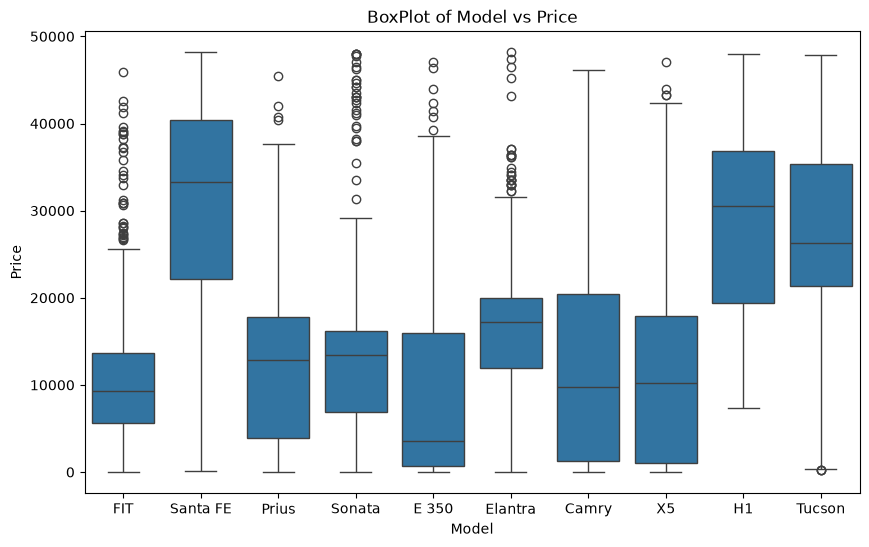

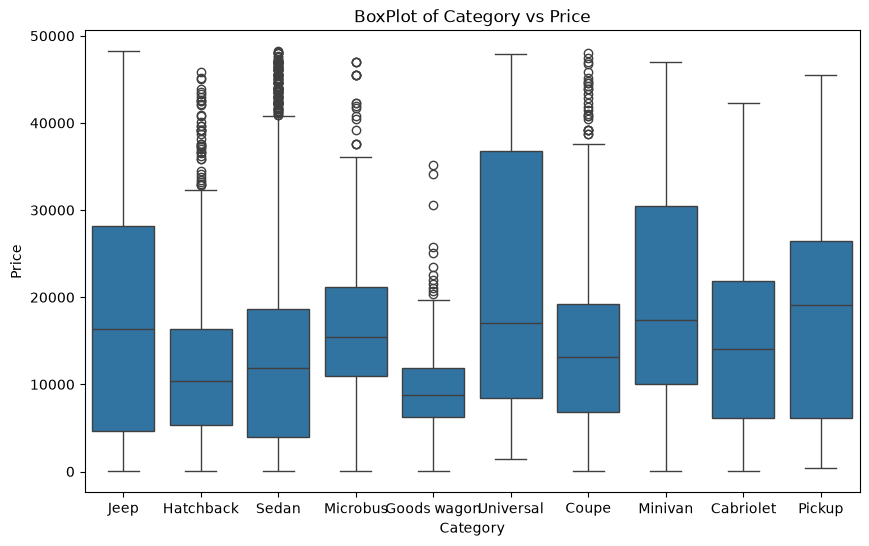

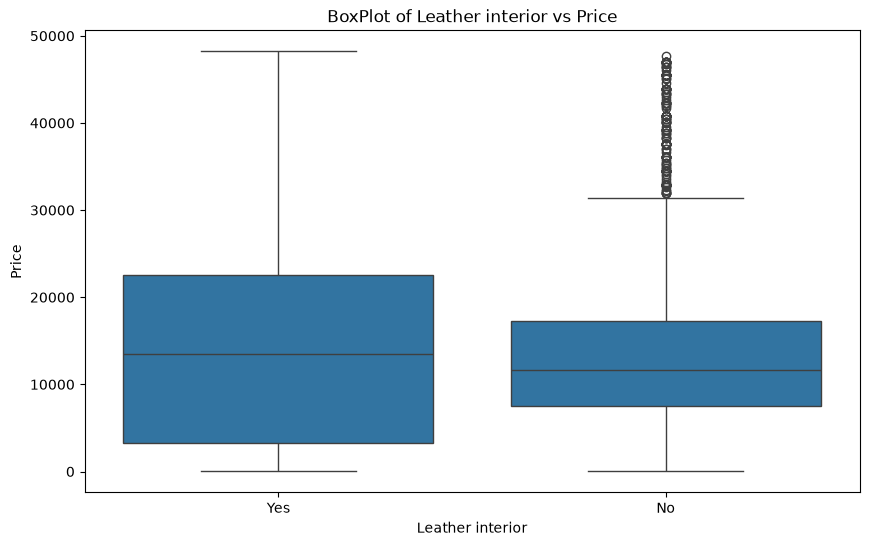

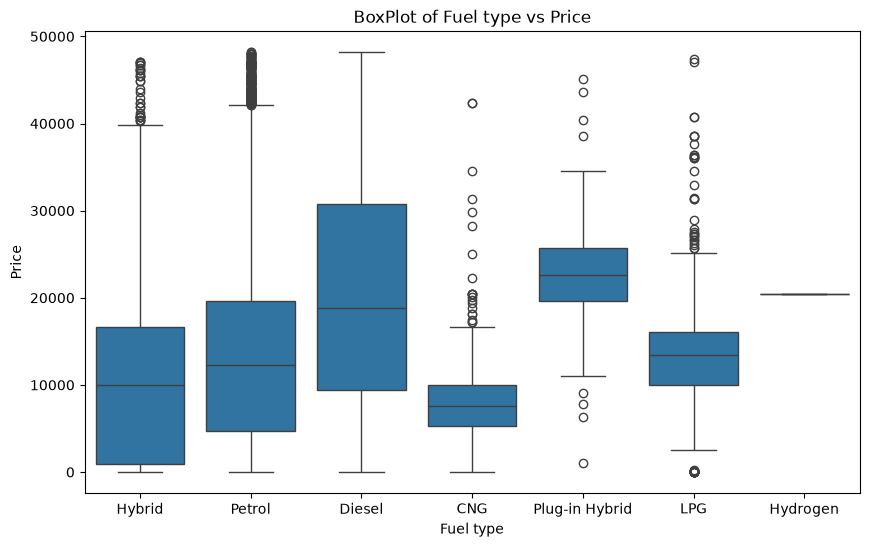

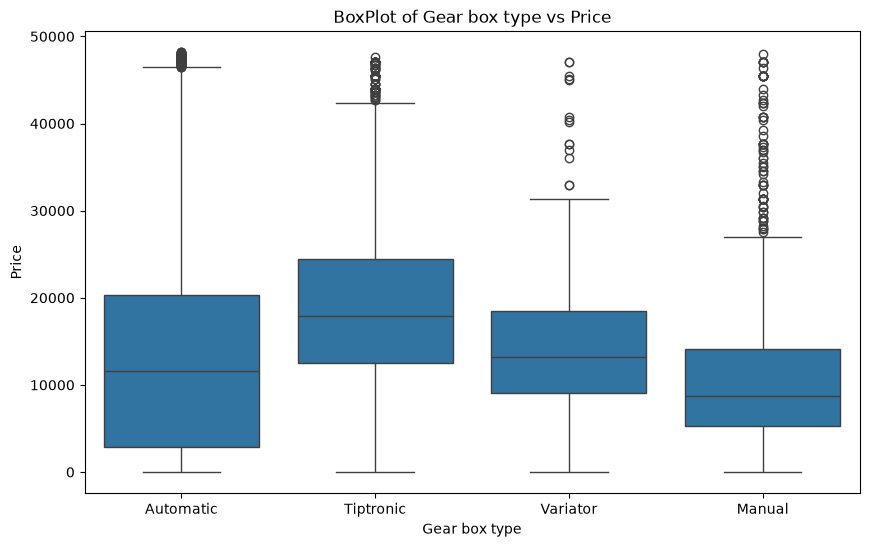

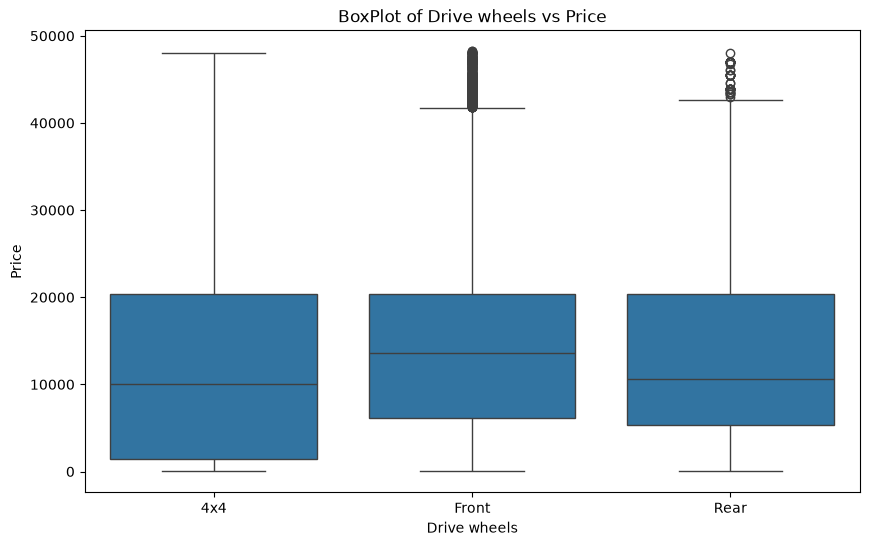

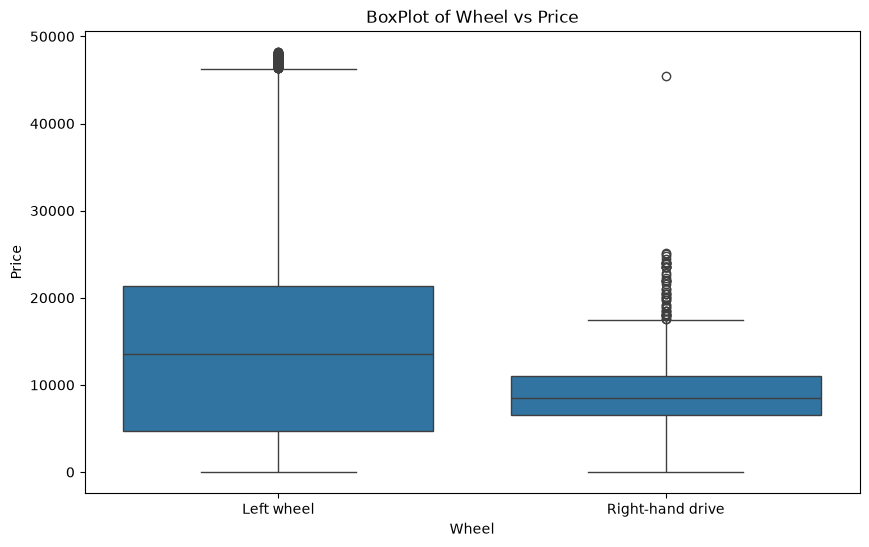

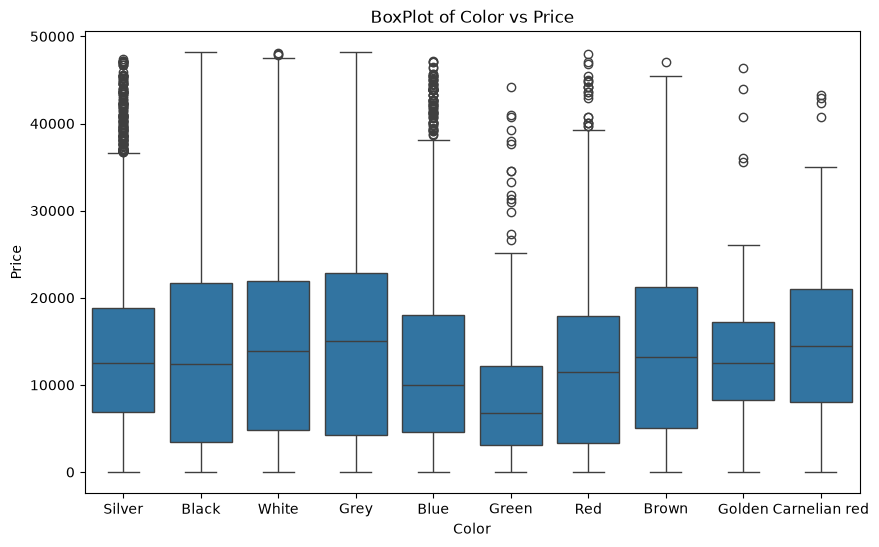

In [27]:
for col in data.select_dtypes('object'):
    top_categories = data[col].value_counts().index[:10]
    filtered_data = data[data[col].isin(top_categories)]
    
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=filtered_data[col], y=filtered_data['Price'])
    plt.title(f'BoxPlot of {col} vs Price')

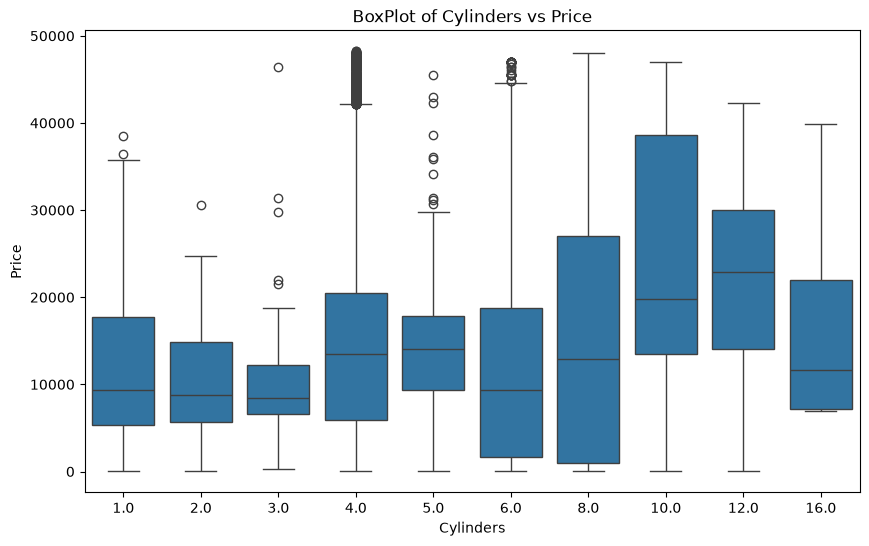

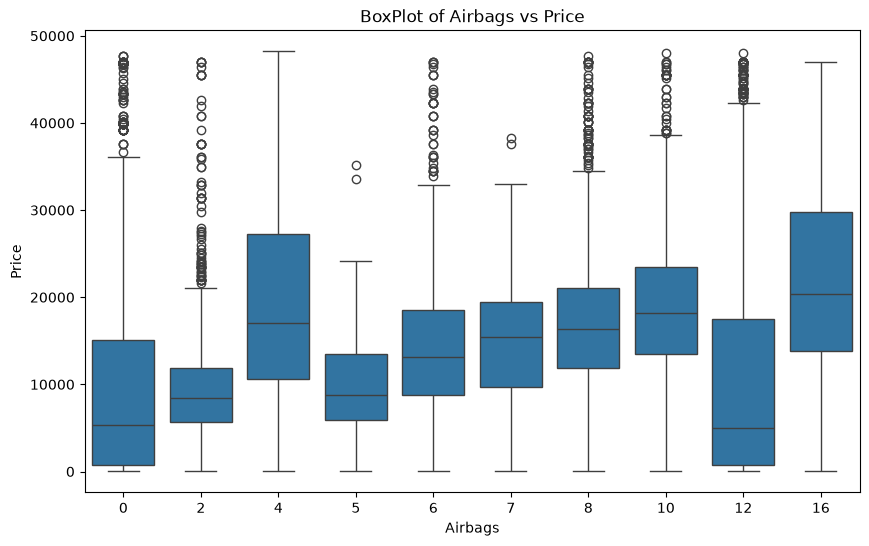

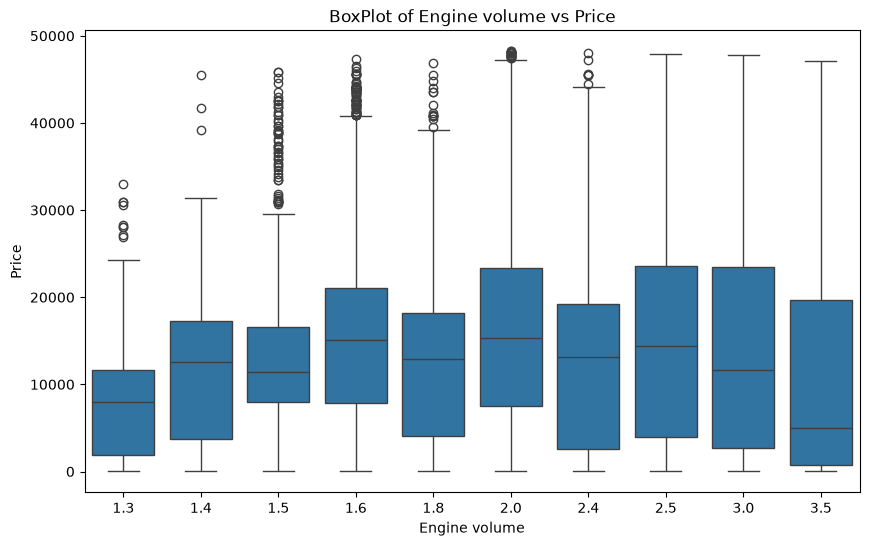

In [28]:
for col in ['Cylinders', 'Airbags', 'Engine volume']:
    top_categories = data[col].value_counts().index[:10]
    filtered_data = data[data[col].isin(top_categories)]
    
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=filtered_data[col], y=filtered_data['Price'])
    plt.title(f'BoxPlot of {col} vs Price')